In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
train = pd.read_csv('../data/train.csv', parse_dates=['date'])
test = pd.read_csv('../data/test.csv', parse_dates=['date'])
sample_sub = pd.read_csv('../data/sample_submission.csv')


print("--- Данные продаж (Train) ---")
display(train.head())

train.info()
train.describe()

--- Данные продаж (Train) ---


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


Добавляем признаки 


In [2]:

train['day_of_week'] = train['date'].dt.dayofweek
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['sales_lag_1'] = train.groupby(['store', 'item'])['sales'].shift(1)
# продажи ровно неделю назад
train['sales_lag_7'] = train.groupby(['store', 'item'])['sales'].shift(7)
train['sales_lag_30'] = train.groupby(['store', 'item'])['sales'].shift(30)
# Окно в 7 дней (rolling mean)
train['sales_rolling_mean_7'] = train.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())
train['sales_rolling_mean_30'] = train.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=30).mean())
# Профиль магазина за весь период 
store_size = train.groupby('store')['sales'].mean().reset_index()
store_size.columns = ['store', 'store_avg_sales']
# Профиль товара
item_popularity = train.groupby('item')['sales'].mean().reset_index()
item_popularity.columns = ['item', 'item_avg_sales']
# Объединяем за весь период 
cols_to_drop = ['item_avg_sales', 'store_avg_sales']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])

train = train.merge(item_popularity, on='item', how='left')
# Объединяем с основной таблицей
train = train.merge(store_size, on='store', how='left')



manual_holidays = [
    (1, 1), (12, 31), (12, 30),   # Новый год
    (2, 14), (2, 13),             # День Валентина
    (7, 4), (7, 3),               # День независимости
    (10, 31), (10, 30),           # Хэллоуин
    (11, 24), (11, 23),           # Благодарение
    (12, 25), (12, 24), (12, 23)  # Рождество
]

# 2. Создаем функцию для проверки
def check_holiday(row):
    # Проверяем, совпадает ли месяц и день с нашим списком
    if (row.month, row.day) in manual_holidays:
        return 1
    return 0

# 3. Применяем к нашему train
train['is_holiday'] = train['date'].apply(check_holiday)

# 4. Добавим "эффект выходного"
train['is_shopping_day'] = train['day_of_week'].isin([4, 5]).astype(int)


train.dropna(inplace=True)


train.info()
train.describe()

<class 'pandas.DataFrame'>
Index: 898000 entries, 30 to 912999
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   898000 non-null  datetime64[us]
 1   store                  898000 non-null  int64         
 2   item                   898000 non-null  int64         
 3   sales                  898000 non-null  int64         
 4   day_of_week            898000 non-null  int32         
 5   month                  898000 non-null  int32         
 6   year                   898000 non-null  int32         
 7   sales_lag_1            898000 non-null  float64       
 8   sales_lag_7            898000 non-null  float64       
 9   sales_lag_30           898000 non-null  float64       
 10  sales_rolling_mean_7   898000 non-null  float64       
 11  sales_rolling_mean_30  898000 non-null  float64       
 12  item_avg_sales         898000 non-null  float64       
 13 

,date,store,item,sales,day_of_week,month,year,sales_lag_1,sales_lag_7,sales_lag_30,sales_rolling_mean_7,sales_rolling_mean_30,item_avg_sales,store_avg_sales,is_holiday,is_shopping_day
count,898000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000,898000.000000
mean,2015-07-17 12:00:00,5.500000,25.500000,52.632886,3.003341,6.615813,2015.033964,52.618378,52.574706,52.375058,52.591662,52.496495,52.250287,52.250287,0.038419,0.286192
min,2013-01-31 00:00:00,1.000000,1.000000,0.000000,0.000000,1.000000,2013.000000,0.000000,0.000000,0.000000,5.571429,6.766667,18.358708,36.363735,0.000000,0.000000
25%,2014-04-24 18:00:00,3.000000,13.000000,30.000000,1.000000,4.000000,2014.000000,30.000000,30.000000,30.000000,30.714286,30.733333,29.398193,39.770164,0.000000,0.000000
50%,2015-07-17 12:00:00,5.500000,25.500000,47.000000,3.000000,7.000000,2015.000000,47.000000,47.000000,47.000000,48.142857,48.100000,51.371358,54.975986,0.000000,0.000000
75%,2016-10-08 06:00:00,8.000000,38.000000,70.000000,5.000000,10.000000,2016.000000,70.000000,70.000000,70.000000,69.857143,69.700000,69.634940,59.530602,0.000000,1.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000,6.000000,12.000000,2017.000000,231.000000,231.000000,231.000000,175.428571,165.800000,88.030778,67.033165,1.000000,1.000000
std,NaN,2.872283,14.430878,28.820823,1.999720,3.401897,1.401743,28.822720,28.833726,28.876637,27.012856,26.802233,21.314177,10.291573,0.192205,0.451980


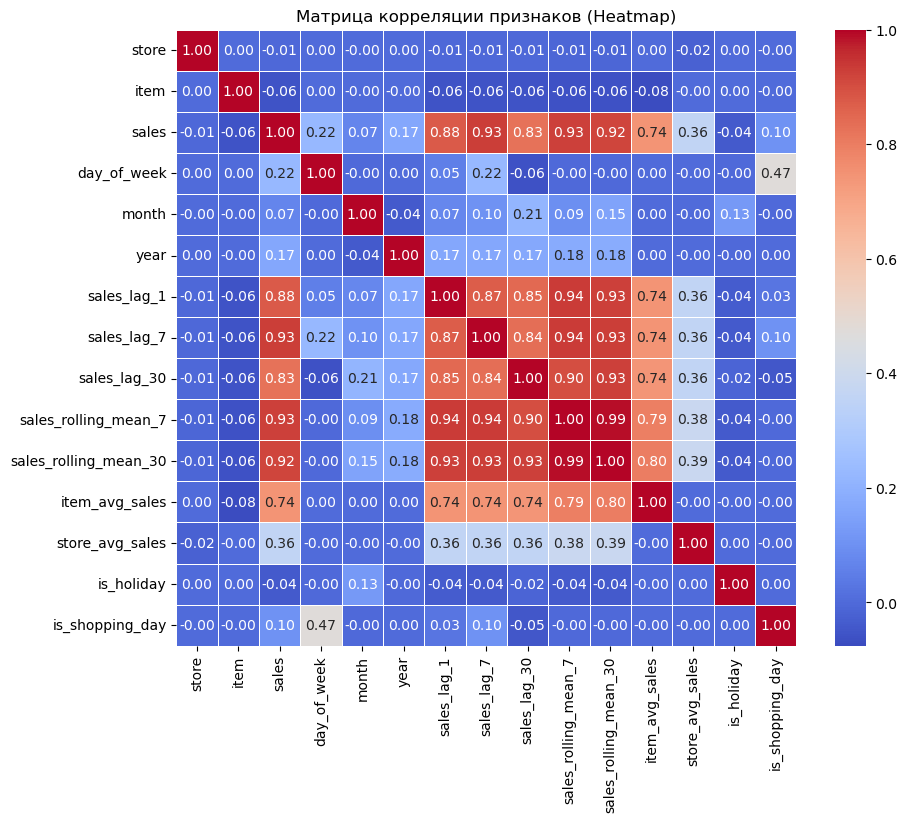

In [3]:


# Выбираем только числовые колонки для корреляции
corr_matrix = train.drop('date', axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков (Heatmap)')
plt.show()

Для ячейки ниже Переключится на ядро с Нампай <2 для выполения


In [ ]:
import sweetviz as sv

report = sv.analyze(train ,pairwise_analysis = 'on')
report.show_html('Report.html')

Сохраняем данные

In [7]:
import os

# 1. Определяем путь к папке data. 
# Если ноутбук в папке notebooks/, а папка data в корне, то идем на уровень вверх '..'
output_dir = '../data' 

# 2. Проверяем, существует ли папка. Если нет — создаем её.
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Папка {output_dir} была создана!")

# 3. Сохраняем файл
file_path = os.path.join(output_dir, 'train_cleaned.csv')
train.to_csv(file_path, index=False)

print(f"Данные успешно сохранены по пути: {file_path}")

Данные успешно сохранены по пути: ../data\train_cleaned.csv


Данные сохранены в data/train_cleaned.csv
